In [2]:
import numpy as np
from PIL import Image
import pandas as pd
import cv2
from skimage import io, transform, color
import os 
import matplotlib.pyplot as plt
import pydicom

# Read the CSV file from specifix path in external CD
breast_level_annotations = pd.read_csv('E:/PhD/V_M_Dataset/breast-level_annotations.csv')
# Read the CSV file
finding_annotations = pd.read_csv('E:/PhD/V_M_Dataset/finding_annotations.csv')
metadata = pd.read_csv('E:/PhD/V_M_Dataset/metadata.csv')
#for our interes we create the new DB with important columns in owr interes.
selected_columns_BLA = breast_level_annotations[[ 'study_id' , 'series_id', 'image_id', 'breast_birads', 'split','laterality' , 'view_position', 'breast_density']]

selected_columns_BLA.head()

,study_id,series_id,image_id,breast_birads,split,laterality,view_position,breast_density
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,BI-RADS 2,training,L,CC,DENSITY C
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,BI-RADS 2,training,L,MLO,DENSITY C
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,BI-RADS 2,training,R,CC,DENSITY C
3,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,71638b1e853799f227492bfb08a01491,BI-RADS 2,training,R,MLO,DENSITY C
4,8269f5971eaca3e5d3772d1796e6bd7a,d931832a0815df082c085b6e09d20aac,dd9ce3288c0773e006a294188aadba8e,BI-RADS 1,training,L,CC,DENSITY C


# A function to crate masks for not brest part visible in mammography

Strategy for Creating Masks for U-Net

1) The processed image (resized + text removed) is displayed to the user.

2) The user is asked whether to create a mask for this image or not.

   -- If the answer is “0” (no):
   
   ---- The image is saved in image_directory.
   
   ---- An empty mask (only 0s) with the same size as the image is created and saved in mask_directory.

   -- If the answer is “1” (yes):
   
   ---- The user provides a row number (row_coord) where the mask should start.
   
   ---- A binary mask is created from the image.
   
   ---- Pixels above row_coord are set to 0 (removed area).
   
   ---- Pixels below row_coord remain 1 (or 255 in binary grayscale format).
   
   ---- The processed image is saved in image_directory and the corresponding mask in mask_directory.
   
   ---- The mask is displayed for visual verification.

3) If the user provides an invalid response:
   -- The function ignores that image and proceeds to the next one.

In [13]:
def create_masks_from_dicom(selected_rows, dicom_directory, image_directory, mask_directory):
    os.makedirs(image_directory, exist_ok=True)
    os.makedirs(mask_directory, exist_ok=True)
    
    nr_sakt = 0
    nr_gabim = 0

    for i, row in selected_rows.iterrows():
        dicom_image_path = os.path.join(dicom_directory, row[0], row[2] + '.dicom')
        dicom_data = pydicom.dcmread(dicom_image_path)
        dicom_pixels = dicom_data.pixel_array

        # Norm 0–255
        normalized_pixels = ((dicom_pixels - np.min(dicom_pixels)) /
                             (np.max(dicom_pixels) - np.min(dicom_pixels)) * 255).astype(np.uint8)

        # delete text on eg
        clean_image_from_text = delete_text_writen_in_image(normalized_pixels, window_size=(700, 700))

        # Resize në (256, 256)
        resized_image = cv2.resize(clean_image_from_text, (256, 256))

        # display
        plt.figure(figsize=(6,6))
        plt.imshow(resized_image, cmap='gray')
        for r in range(0, resized_image.shape[0], 10):
            plt.axhline(y=r, color='red', linewidth=0.5, alpha=0.5)
        for c in range(0, resized_image.shape[1], 10):
            plt.axvline(x=c, color='blue', linewidth=0.5, alpha=0.3)
        plt.yticks(np.arange(0, resized_image.shape[0], 10))  # for every 10 pixel
        plt.title(f"Imazhi {i} me vizat")
        plt.show()

        
        user_choice = input("Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): ").strip()

        if user_choice == "0":
            cv2.imwrite(os.path.join(image_directory, f"{i}.jpg"), resized_image)
            empty_mask = np.zeros_like(resized_image, dtype=np.uint8)
            cv2.imwrite(os.path.join(mask_directory, f"{i}_maska.jpg"), empty_mask)
            continue

        elif user_choice == "1":
            row_coord = int(input(f"Shkruaj numrin e rreshtit (0-{resized_image.shape[0]-1}) ku fillon maska: "))
            
            # fisrst mask(macro)
            _, binary_mask = cv2.threshold(resized_image, 1, 255, cv2.THRESH_BINARY)
            binary_mask[:row_coord, :][binary_mask[:row_coord, :] == 255] = 0

            # save mask and img
            cv2.imwrite(os.path.join(image_directory, f"{i}.jpg"), resized_image)
            cv2.imwrite(os.path.join(mask_directory, f"{i}_maska.jpg"), binary_mask)

            # mask created displ
            plt.imshow(binary_mask, cmap='gray')
            plt.title(f"Maska për imazhin {i}")
            plt.show()

        else:
            print("Pergjigje e pasakte, kalojmë tek imazhi tjetër.")

    print(f"Procesi përfundoi. Numri i imazheve me maskë: {nr_sakt}, pa maskë: {nr_gabim}")


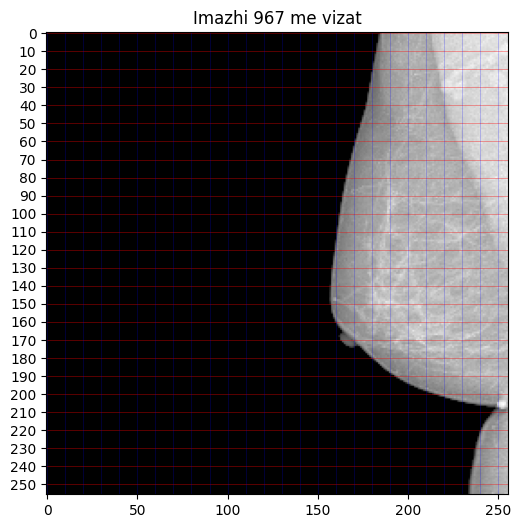

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 209


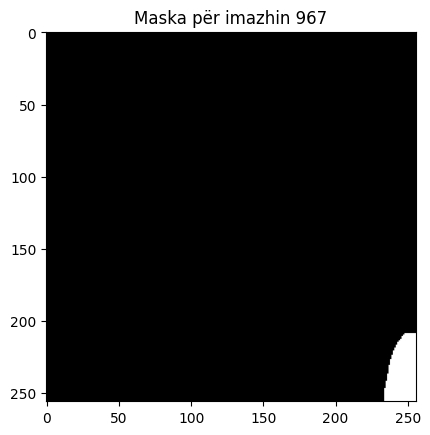

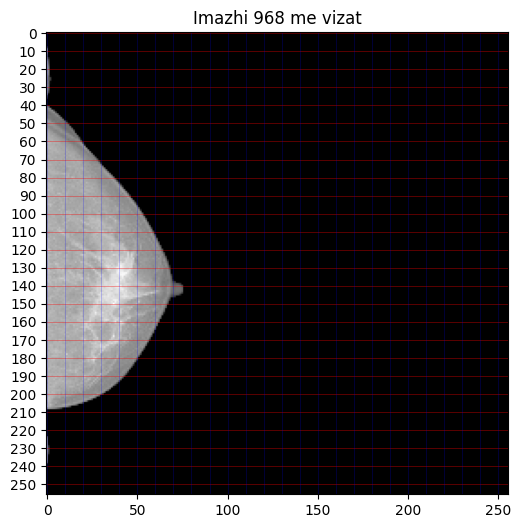

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


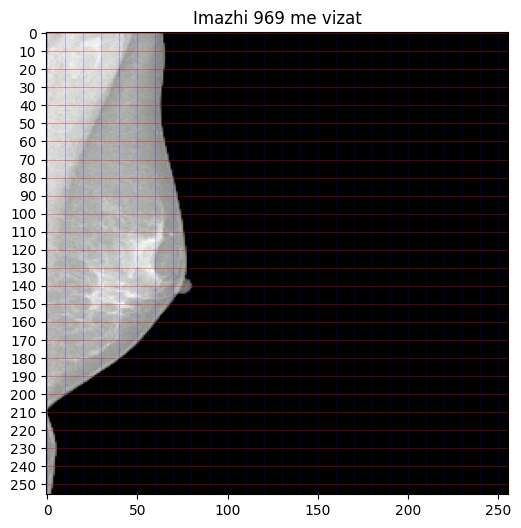

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 210


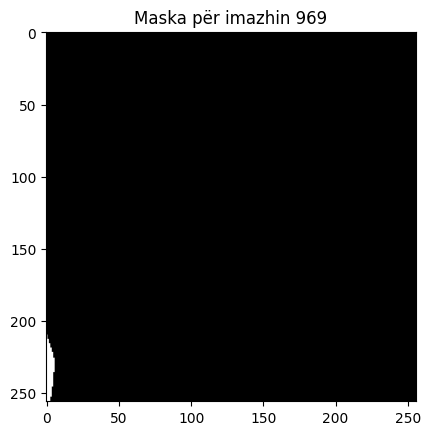

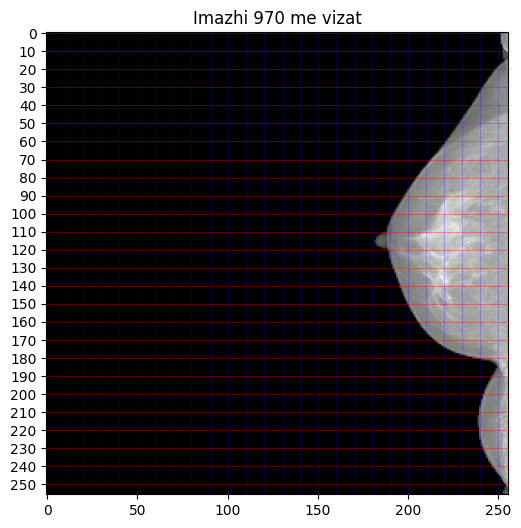

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 188


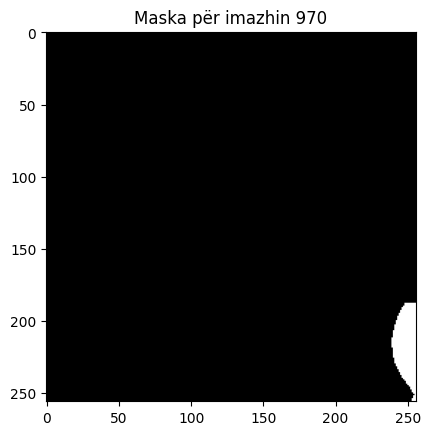

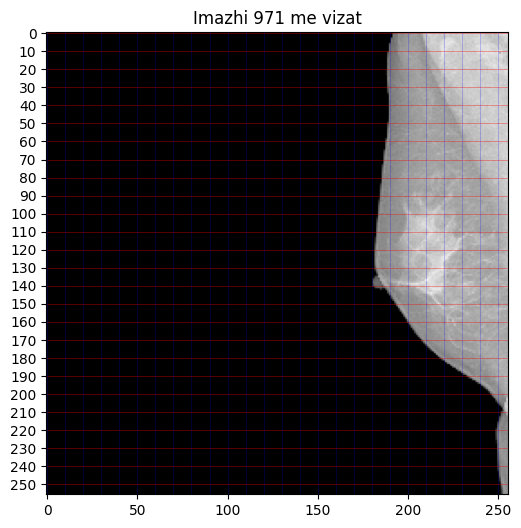

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 208


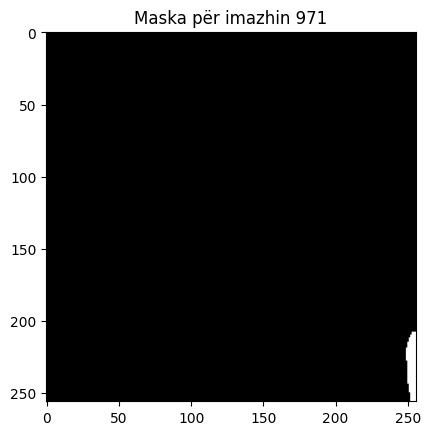

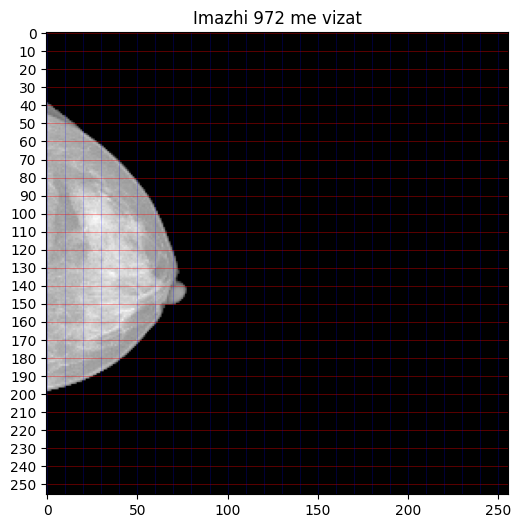

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


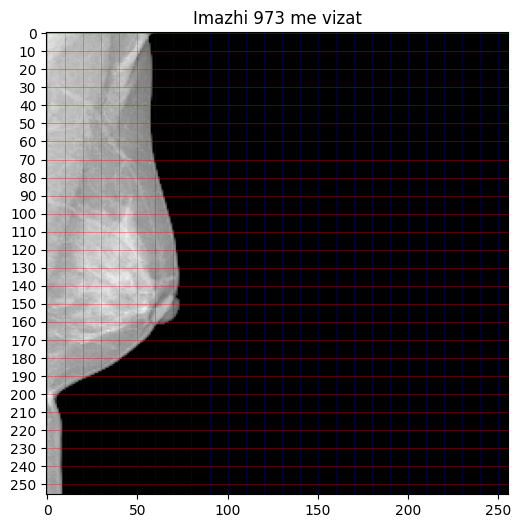

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 201


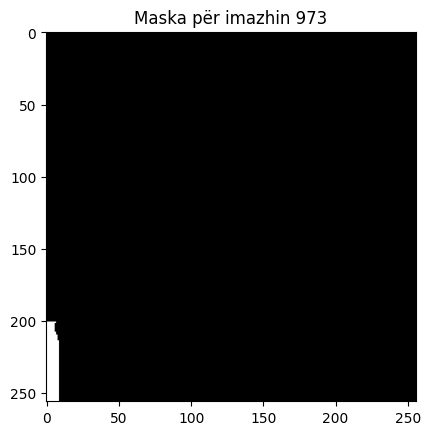

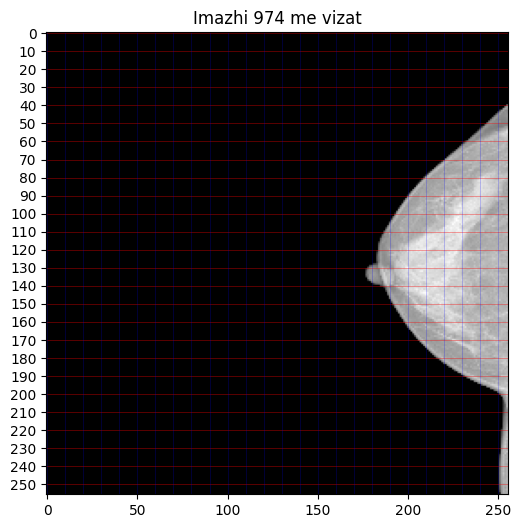

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 201


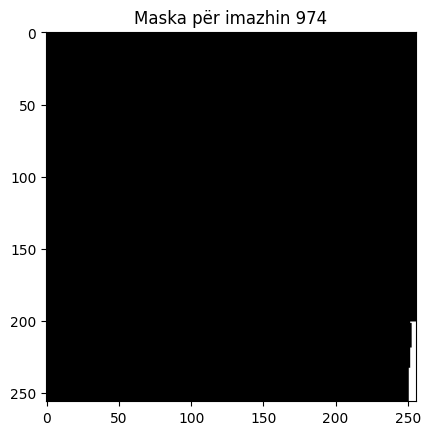

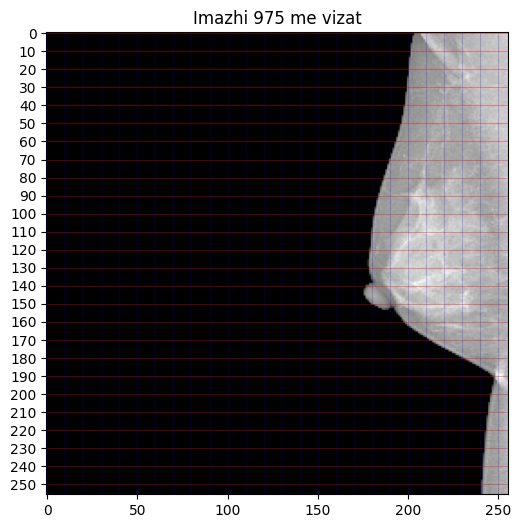

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 190


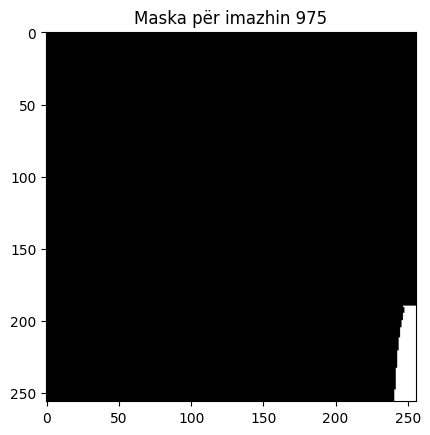

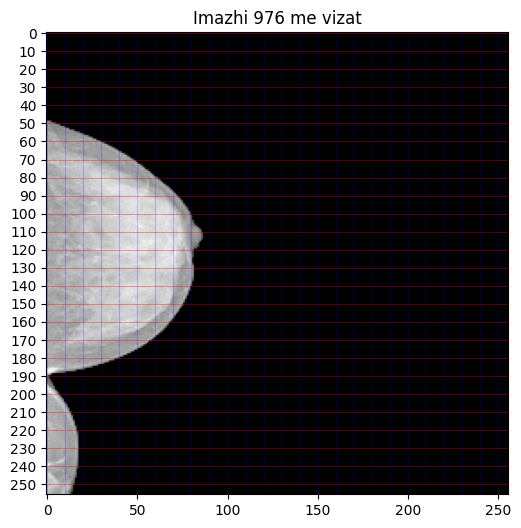

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 190


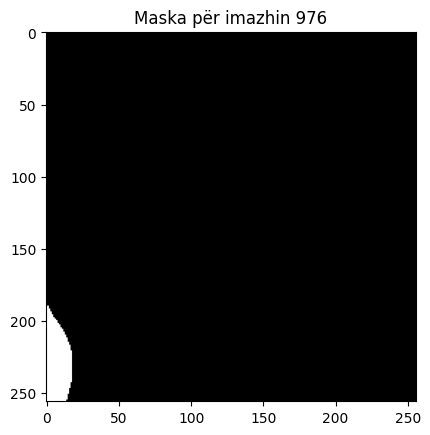

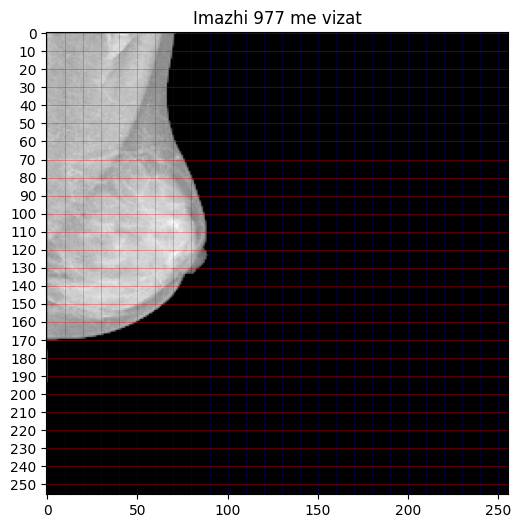

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


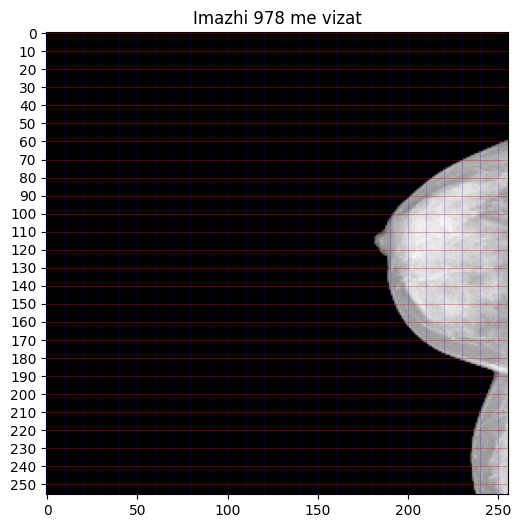

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 188


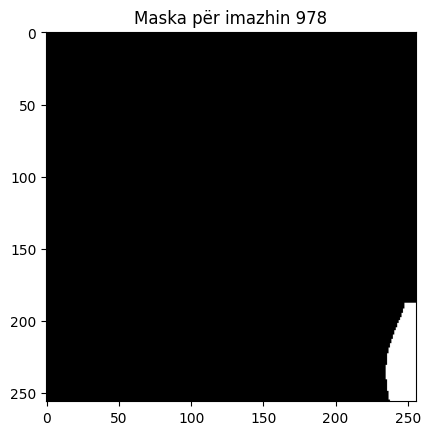

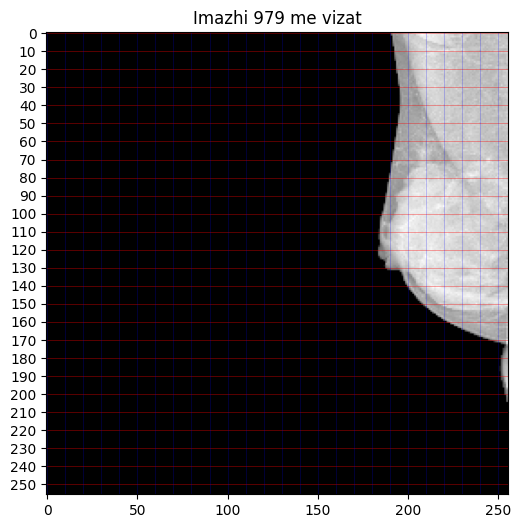

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 172


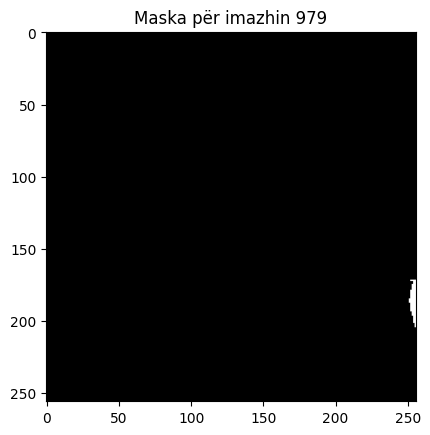

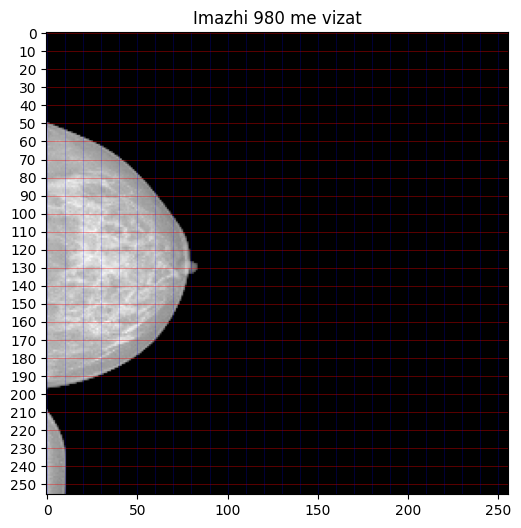

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 200


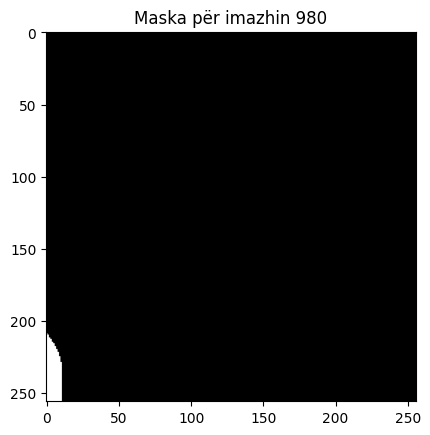

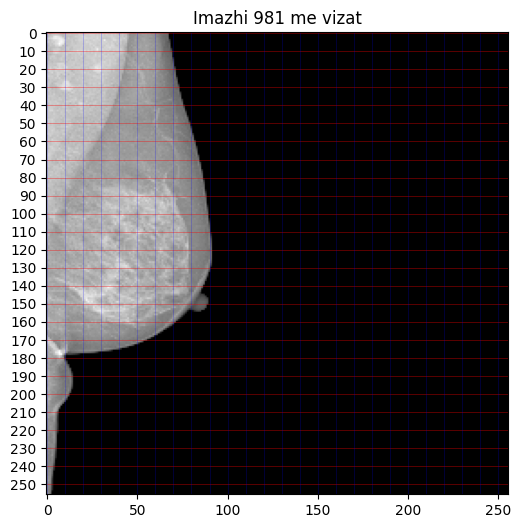

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 180


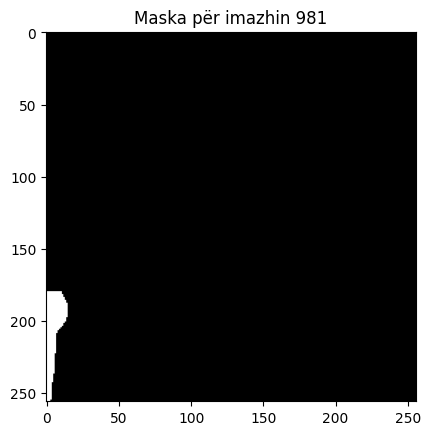

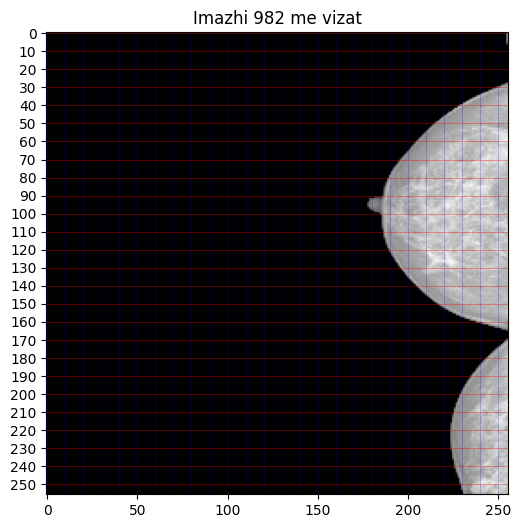

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 170


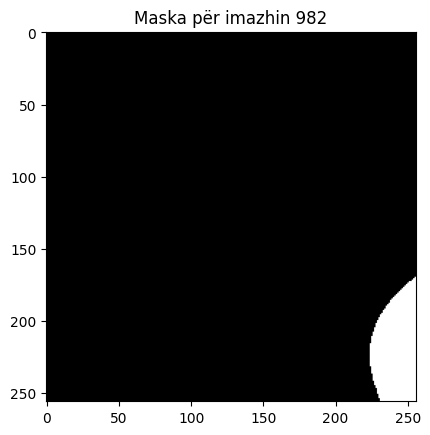

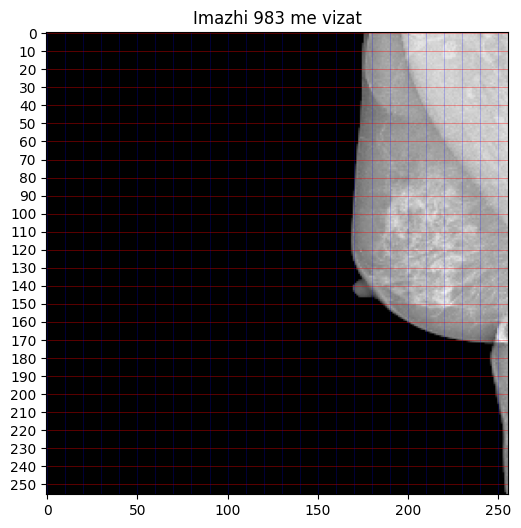

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 173


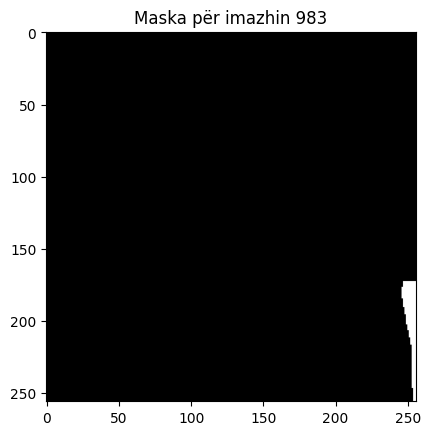

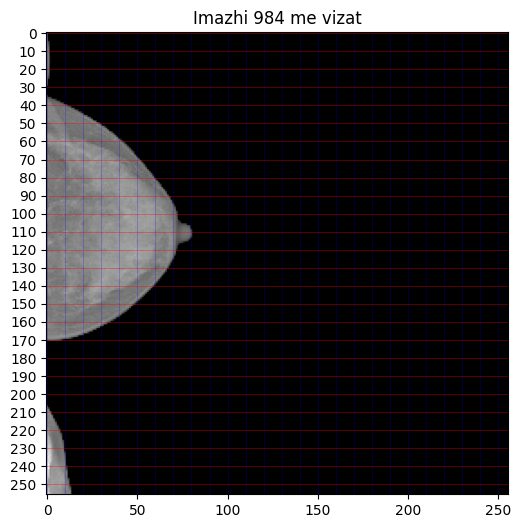

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 180


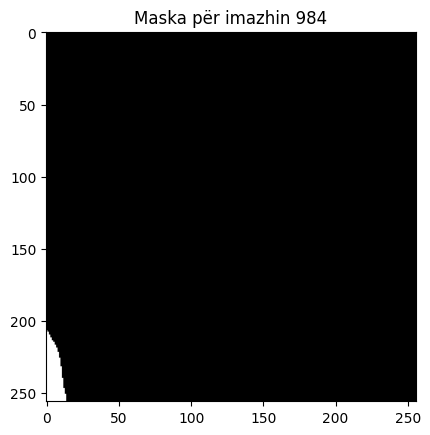

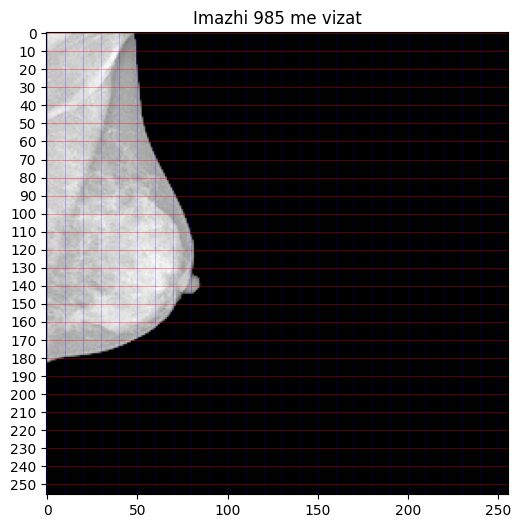

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


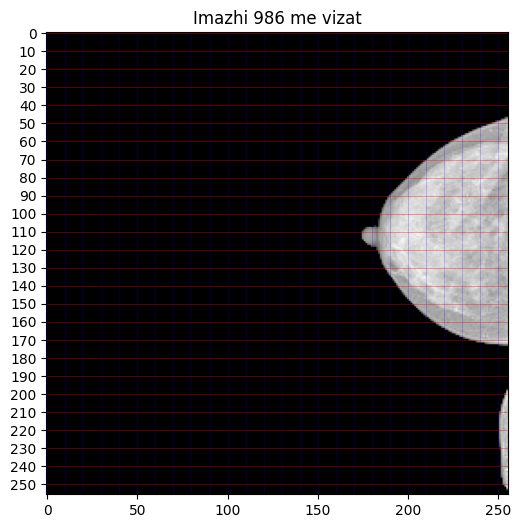

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 190


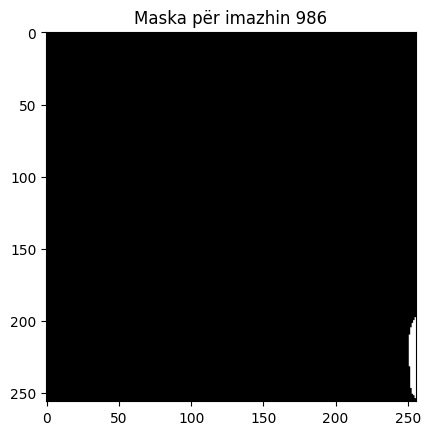

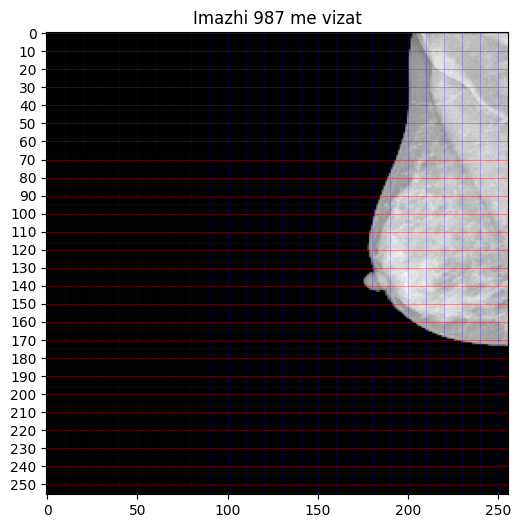

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


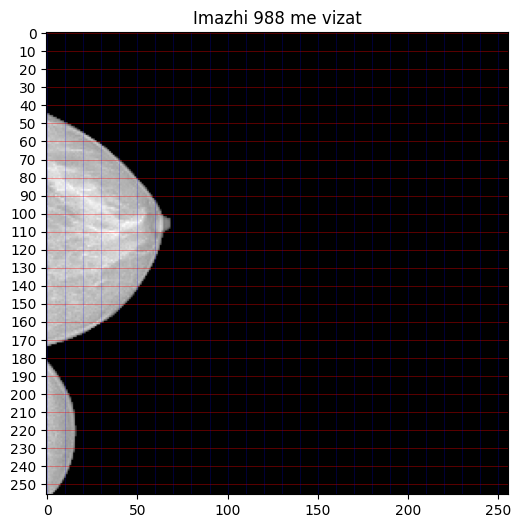

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 180


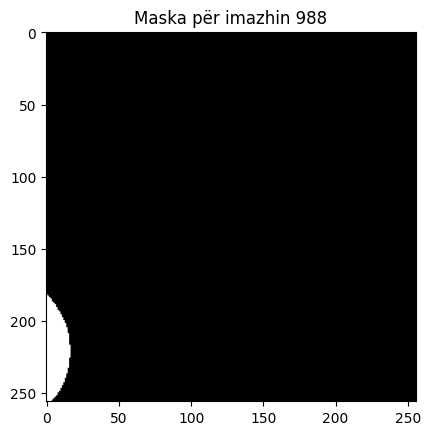

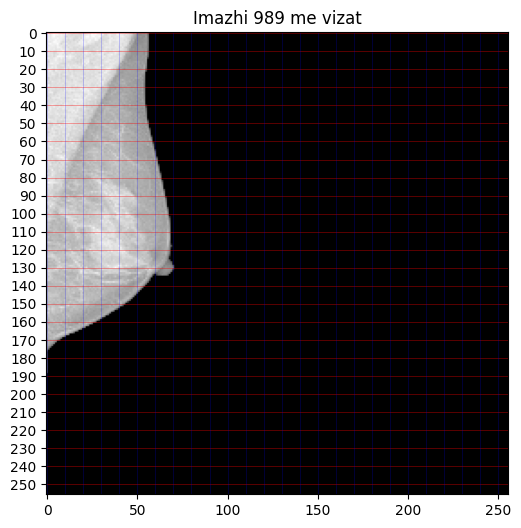

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


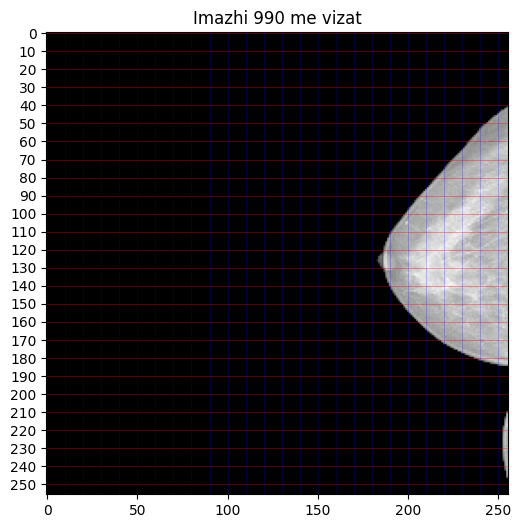

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 190


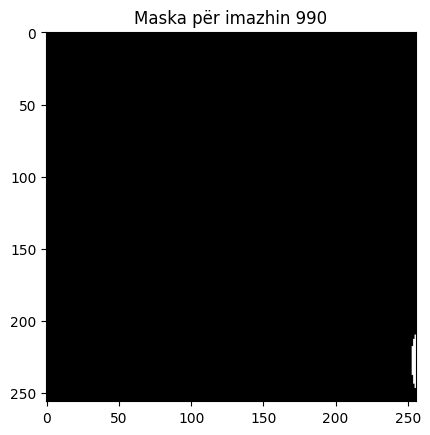

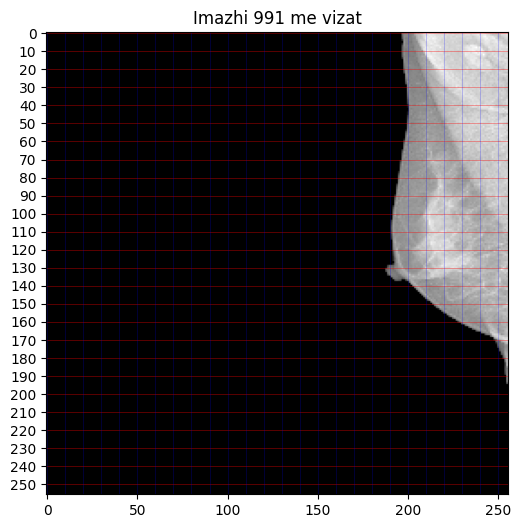

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 170


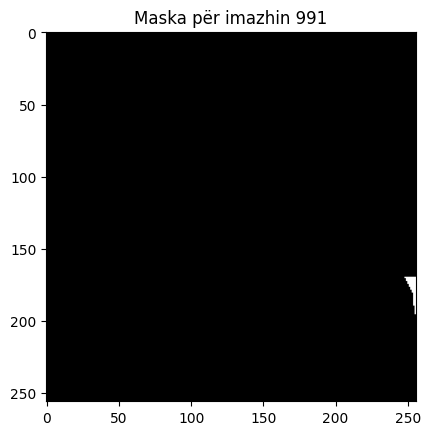

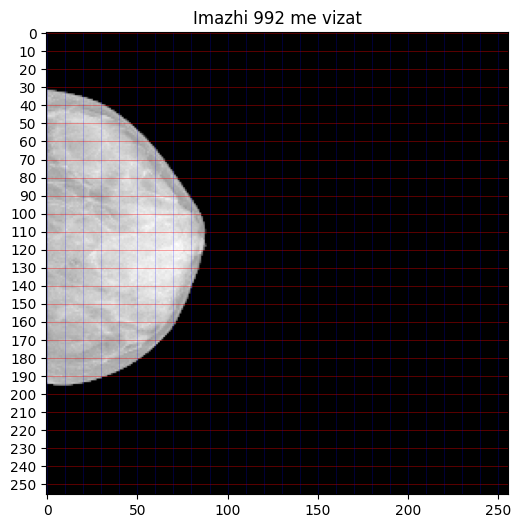

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


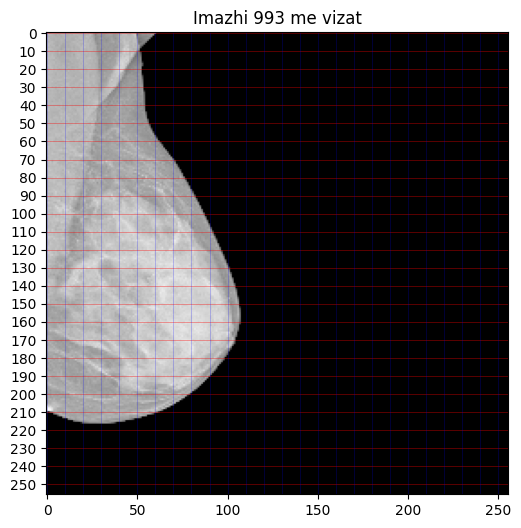

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


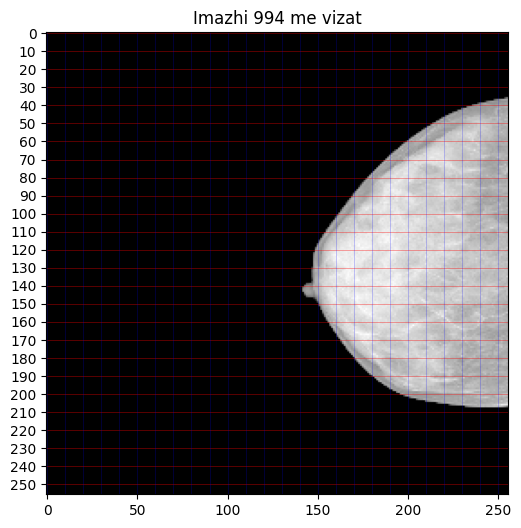

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


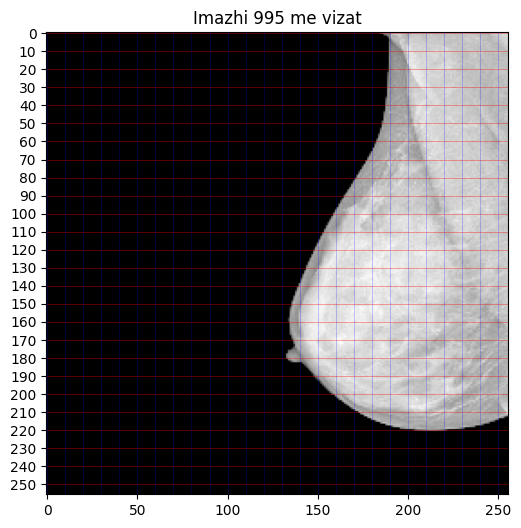

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 2
Pergjigje e pasakte, kalojmë tek imazhi tjetër.


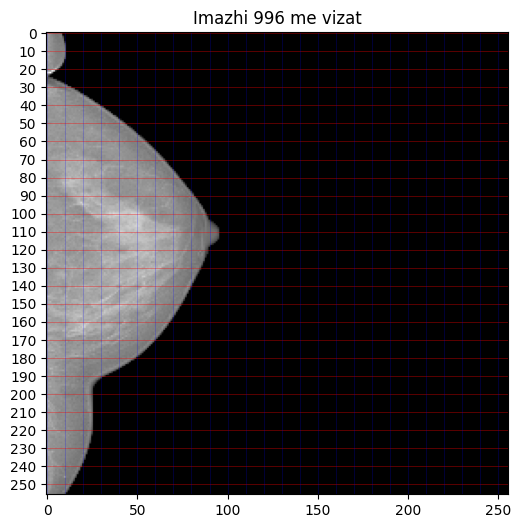

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 194


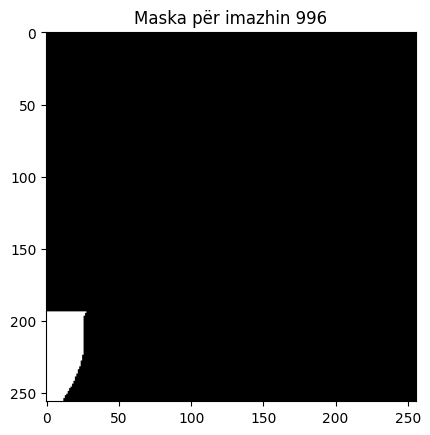

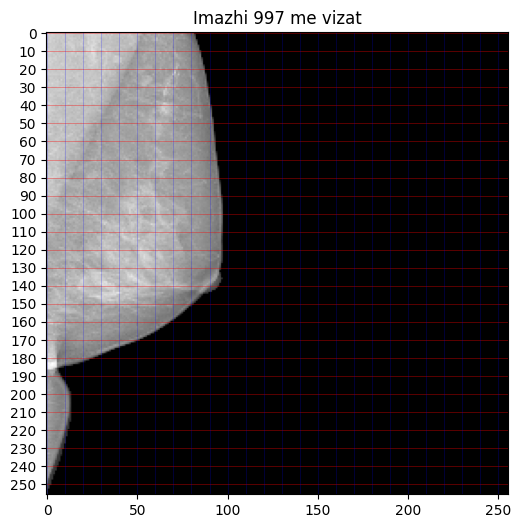

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 185


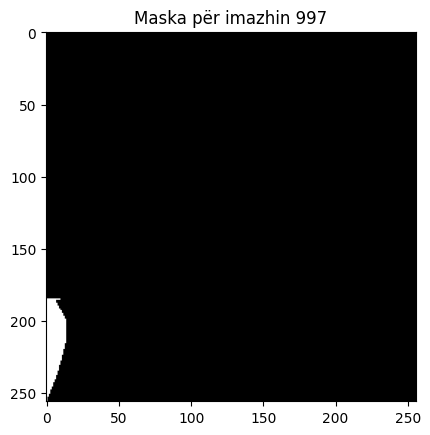

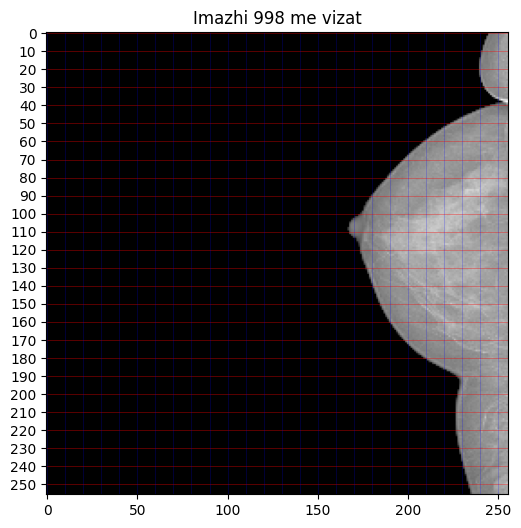

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 190


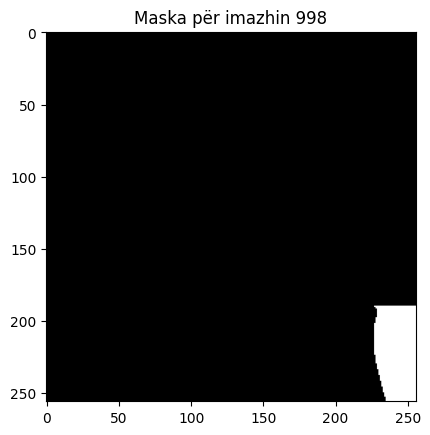

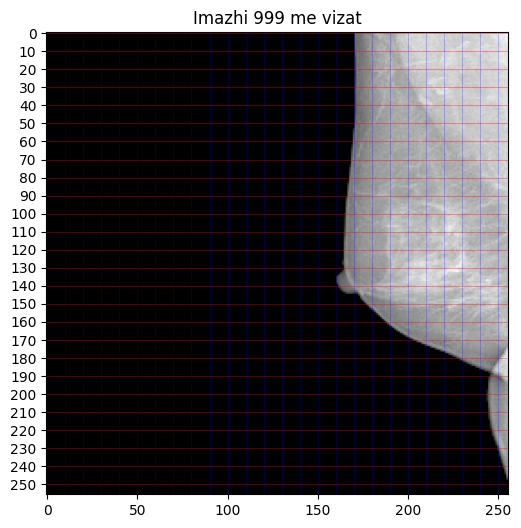

Deshiron te krijosh mask per kete imazh? (1=po, 0=jo): 1
Shkruaj numrin e rreshtit (0-255) ku fillon maska: 189


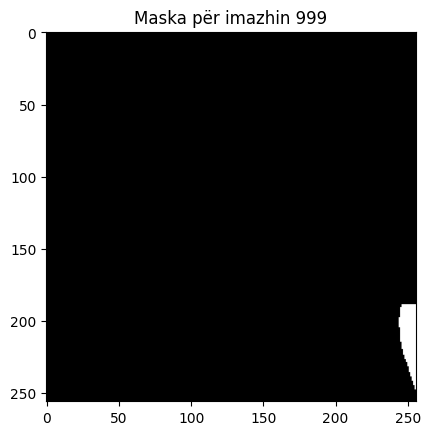

Procesi përfundoi. Numri i imazheve me maskë: 0, pa maskë: 0


In [25]:
create_masks_from_dicom(
    selected_rows=selected_columns_BLA.iloc[967:1000],
    dicom_directory='E:/PhD/V_M_Dataset/images/',
    image_directory='E:/PhD/V_M_Dataset/segmented_file - Copy/images/',
    mask_directory='E:/PhD/V_M_Dataset/segmented_file - Copy/masks_error/'
)
